#Task 1: Data Preparation
**Loading the Data**

• Download the provided folder that contains the Devnagari digits dataset.

• Use the Python Imaging Library (PIL) to load and read the image files from the dataset.

• Convert the images into Numpy arrays and normalize them to a range of 0-1.

• use train folder for training and test for testing.

• Extract the corresponding labels for each image.


In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from PIL import Image # Import Pillow

# Define dataset paths
train_dir = "/content/drive/MyDrive/Collage/SEM 6 AI/Week 4/DevanagariHandwrittenDigitDataset/Train"
test_dir = "/content/drive/MyDrive/Collage/SEM 6 AI/Week 4/DevanagariHandwrittenDigitDataset/Test"
# Define image size
img_height, img_width = 28, 28
# Function to load images and labels using PIL
def load_images_from_folder(folder):
    images = []
    labels = []
    class_names = sorted(os.listdir(folder)) # Sorted class names (digit_0, digit_1, ...)
    class_map = {name: i for i, name in enumerate(class_names)} # Map class names to labels
    print(f"Found classes: {class_names}")
    print(f"Class mapping: {class_map}")
    for class_name in class_names:
      class_path = os.path.join(folder, class_name)
      label = class_map[class_name]
      #file_count = 0
      for filename in os.listdir(class_path):
          img_path = os.path.join(class_path, filename)

          # Load image using PIL
          img = Image.open(img_path).convert("L") # Convert to grayscale
          img = img.resize((img_width, img_height)) # Resize to (28,28)
          img = np.array(img) / 255.0 # Normalize pixel values to [0,1]

          images.append(img)
          labels.append(label)
          #file_count += 1
      #print(f"Loaded {file_count} images from class {class_name}")
    return np.array(images), np.array(labels)

Found classes: ['digit_0', 'digit_1', 'digit_2', 'digit_3', 'digit_4', 'digit_5', 'digit_6', 'digit_7', 'digit_8', 'digit_9']
Class mapping: {'digit_0': 0, 'digit_1': 1, 'digit_2': 2, 'digit_3': 3, 'digit_4': 4, 'digit_5': 5, 'digit_6': 6, 'digit_7': 7, 'digit_8': 8, 'digit_9': 9}
Found classes: ['digit_0', 'digit_1', 'digit_2', 'digit_3', 'digit_4', 'digit_5', 'digit_6', 'digit_7', 'digit_8', 'digit_9']
Class mapping: {'digit_0': 0, 'digit_1': 1, 'digit_2': 2, 'digit_3': 3, 'digit_4': 4, 'digit_5': 5, 'digit_6': 6, 'digit_7': 7, 'digit_8': 8, 'digit_9': 9}
Training set: (17013, 28, 28, 1), Labels: (17013, 10)
Testing set: (3000, 28, 28, 1), Labels: (3000, 10)


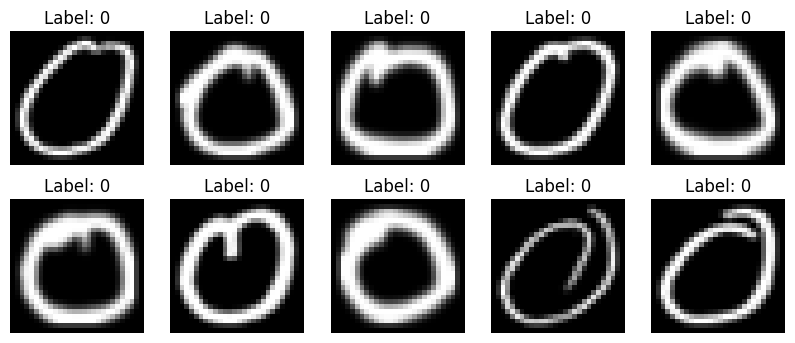

In [ ]:

# Load training and testing datasets
x_train, y_train = load_images_from_folder(train_dir)
x_test, y_test = load_images_from_folder(test_dir)
# Reshape images for Keras input
x_train = x_train.reshape(-1, img_height, img_width, 1) # Shape (num_samples, 28, 28, 1)
x_test = x_test.reshape(-1, img_height, img_width, 1)
# One-hot encode labels
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)
# Print dataset shape
print(f"Training set: {x_train.shape}, Labels: {y_train.shape}")
print(f"Testing set: {x_test.shape}, Labels: {y_test.shape}")
# Visualize some images
plt.figure(figsize=(10, 4))
for i in range(10):
  plt.subplot(2, 5, i + 1)
  plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
  plt.title(f"Label: {np.argmax(y_train[i])}")
  plt.axis("off")
plt.show()

#Task 2: Build the FCN Model
**Model Architecture**

• Create a Sequential model using Keras.

• Add 3 hidden layers with the following number of neurons:

– 1st hidden layer: 64 neurons

– 2nd hidden layer: 128 neurons

– 3rd hidden layer: 256 neurons

• Use sigmoid activation functions for all hidden layers.

• Add an output layer with 10 units with softmax (since Devnagari digits have 10 classes) and a
softmax activation function.

In [ ]:
# Model parameters
import tensorflow as tf
from tensorflow import keras
num_classes = 10
input_shape = (28, 28, 1)
model = keras.Sequential(
  [
    keras.layers.Input(shape=input_shape),
    keras.layers.Flatten(), # Flatten the 28x28 image to a 784-dimensional vector
    keras.layers.Dense(64, activation="sigmoid"),
    keras.layers.Dense(128, activation="sigmoid"),
    keras.layers.Dense(256, activation="sigmoid"),
    keras.layers.Dense(num_classes, activation="softmax"),
  ]
)

#Task 3: Compile the Model
**Model Compilation**

• Choose an appropriate optimizer (e.g., Adam), loss function (e.g., sparse categorical crossentropy), and evaluation metric (e.g., accuracy).

In [ ]:
model.compile(
  optimizer="adam", #adam
  loss="categorical_crossentropy", # Loss function for multi-class classification
  metrics=["accuracy"] # Track accuracy during training
)

#Task 4: Train the Model
**Model Training**

• Use the model.fit() function to train the model. Set the batch size to 128 and the number of epochs to 20.

• Use validation split (validation split=0.2) to monitor the model’s performance on validation
data.

• Optionally, use callbacks such as ModelCheckpoint and EarlyStopping for saving the best model and avoiding overfitting.

In [ ]:
batch_size = 128
epochs = 20
# Callbacks
callbacks = [
  keras.callbacks.ModelCheckpoint(filepath="model_at_epoch_{epoch}.keras"),
  keras.callbacks.EarlyStopping(monitor="val_loss", patience=4 ),
]
history = model.fit(
x_train,
y_train,
batch_size=batch_size,
epochs=epochs,
validation_split=0.20,
callbacks=callbacks,
)

Epoch 1/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9636 - loss: 0.1269 - val_accuracy: 0.0000e+00 - val_loss: 10.2766
Epoch 2/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9712 - loss: 0.1051 - val_accuracy: 0.0000e+00 - val_loss: 10.3389
Epoch 3/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9754 - loss: 0.0882 - val_accuracy: 0.0000e+00 - val_loss: 10.4052
Epoch 4/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9807 - loss: 0.0753 - val_accuracy: 0.0000e+00 - val_loss: 10.3553
Epoch 5/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9835 - loss: 0.0642 - val_accuracy: 0.0000e+00 - val_loss: 10.1437
Epoch 6/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9866 - loss: 0.0552 - val_accuracy: 0.0000e+00 - val_loss: 10.4124
Epoch 7/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9886 - loss: 0.0474 - val_accuracy: 0.0000e+00 - val_loss: 10.6816
Epoch 8/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.991

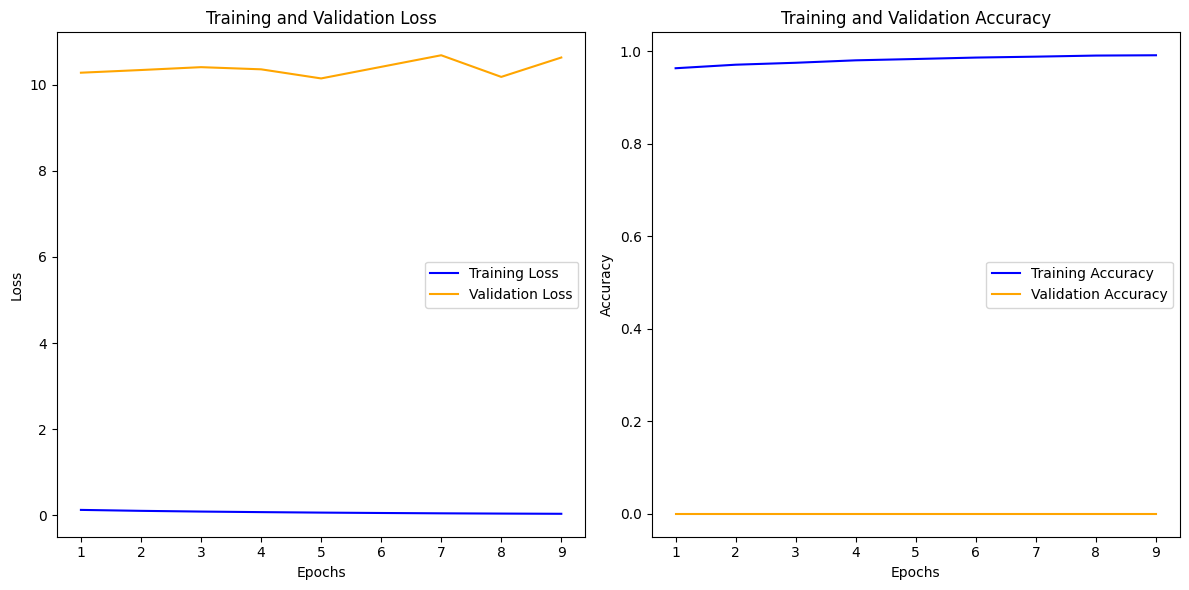

In [ ]:
import matplotlib.pyplot as plt
# Assuming ’history’ is the object returned by model.fit()
# Extracting training and validation loss
train_loss = history.history['loss']
val_loss = history.history['val_loss']
# Extracting training and validation accuracy (if metrics were specified)
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
# Plotting training and validation loss
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(range(1, len(train_loss) + 1), train_loss, label='Training Loss', color='blue')
plt.plot(range(1, len(val_loss) + 1), val_loss, label='Validation Loss', color='orange')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
# Plotting training and validation accuracy
plt.subplot(1, 2, 2)
plt.plot(range(1, len(train_acc) + 1), train_acc, label='Training Accuracy', color='blue')
plt.plot(range(1, len(val_acc) + 1), val_acc, label='Validation Accuracy', color='orange')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

#Task 5: Evaluate the Model
**Model Evaluation**

• After training, evaluate the model using model.evaluate() on the test set to check the test
accuracy and loss.

In [ ]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f"Test accuracy: {test_acc:.4f}")

94/94 - 0s - 2ms/step - accuracy: 0.7823 - loss: 2.1912
Test accuracy: 0.7823


#Task 6: Save and Load the Model
**Model Saving and Loading**

• Save the trained model to an .h5 file using model.save().

• Load the saved model and re-evaluate its performance on the test set.

In [ ]:
#Saving the model
model.save("/content/drive/MyDrive/Collage/SEM 6 AI/Week 4/model.h5")

#Loading the model
loaded_model = tf.keras.models.load_model('/content/drive/MyDrive/Collage/SEM 6 AI/Week 4/model.h5')

# Evaluate loaded model
test_loss, test_accuracy = loaded_model.evaluate(x_test, y_test)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7823 - loss: 2.1912
Test Loss: 2.1912
Test Accuracy: 0.7823


# Task 7: Predictions
**Making Predictions**

• Use model.predict() to make predictions on test images.

• Convert the model's predicted probabilities to digit labels using np.argmax().

In [ ]:
# Predict probabilities
predictions = loaded_model.predict(x_test)
import numpy as np

# Convert to class labels
predicted_labels = np.argmax(predictions, axis=1)
# If y_test is one-hot encoded
true_labels = np.argmax(y_test, axis=1)

# Accuracy check
accuracy = np.mean(predicted_labels == true_labels)
print(f"Prediction Accuracy: {accuracy:.4f}")

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Prediction Accuracy: 0.7823


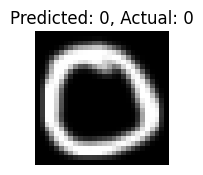

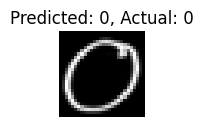

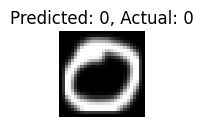

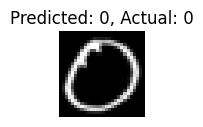

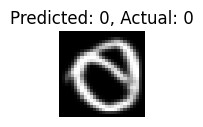

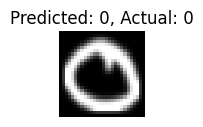

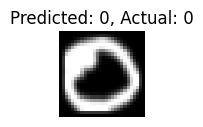

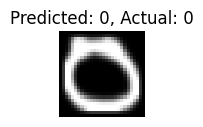

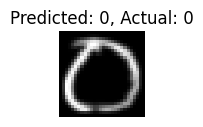

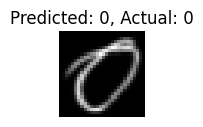

In [ ]:
# Visualize some images
plt.figure(figsize=(10, 4))
for i in range(10):
  plt.subplot(2, 5, i + 1)
  plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
  plt.title(f"Predicted: {predicted_labels[i]}, Actual: {true_labels[i]}")
  plt.axis("off")
  plt.show()

In [ ]:
# Print overall prediction statistics
correct = np.sum(predicted_labels == true_labels)
total = len(true_labels)
print(f"\n--- Prediction Summary ---")
print(f"Correct predictions: {correct}/{total}")
print(f"Overall accuracy: {correct/total:.4f}")

# Per-class accuracy
print(f"\n--- Per-Class Accuracy ---")
for digit in range(10):
    mask = true_labels == digit
    class_correct = np.sum(predicted_labels[mask] == true_labels[mask])
    class_total = np.sum(mask)
    if class_total > 0:
        print(f"Digit {digit}: {class_correct}/{class_total} = {class_correct/class_total:.4f}")


--- Prediction Summary ---
Correct predictions: 2347/3000
Overall accuracy: 0.7823

--- Per-Class Accuracy ---
Digit 0: 300/300 = 1.0000
Digit 1: 297/300 = 0.9900
Digit 2: 290/300 = 0.9667
Digit 3: 284/300 = 0.9467
Digit 4: 297/300 = 0.9900
Digit 5: 292/300 = 0.9733
Digit 6: 293/300 = 0.9767
Digit 7: 294/300 = 0.9800
Digit 8: 0/300 = 0.0000
Digit 9: 0/300 = 0.0000
